In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math

# import import_ipynb
from graph_functions import *
from iterative_pruning_func import *

number of graphs for n=26 : 2


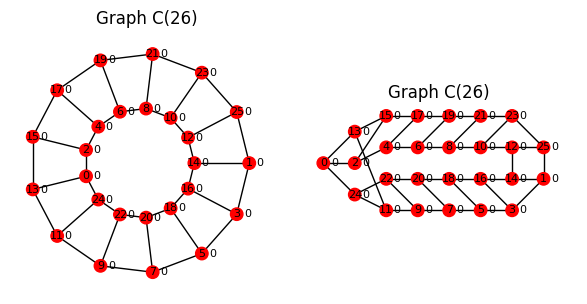

initial removal


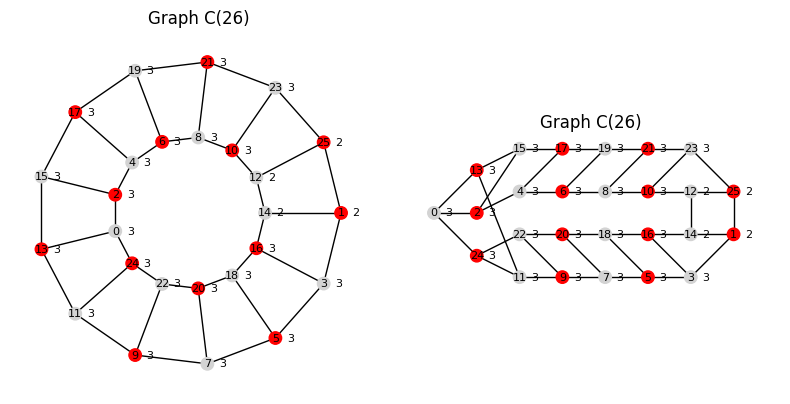

[1, 2, 5, 6, 9, 10, 13, 16, 17, 20, 21, 24, 25]
2
Removed node: None
Healthy nodes after spread: []


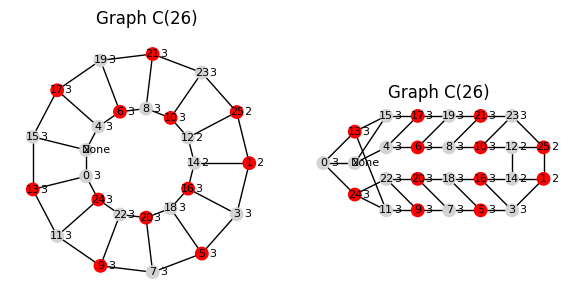

[1, 5, 6, 9, 10, 13, 16, 17, 20, 21, 24, 25]
5
Removed node: None
Healthy nodes after spread: []


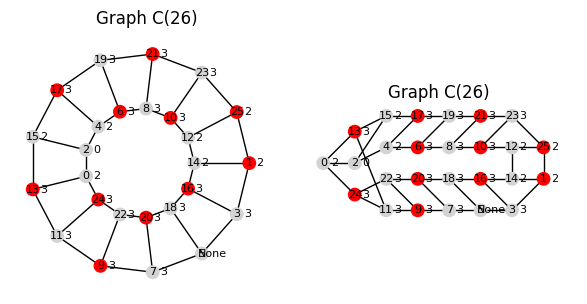

[1, 6, 9, 10, 13, 16, 17, 20, 21, 24, 25]
6
Removed node: None
Healthy nodes after spread: []


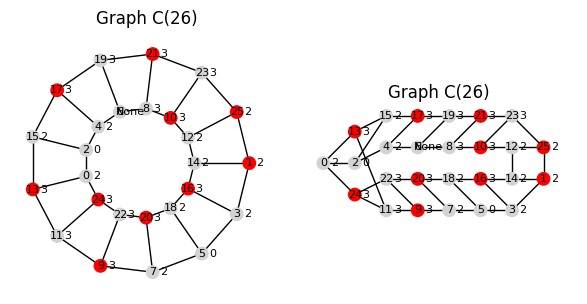

[1, 9, 10, 13, 16, 17, 20, 21, 24, 25]
9
Removed node: None
Healthy nodes after spread: []


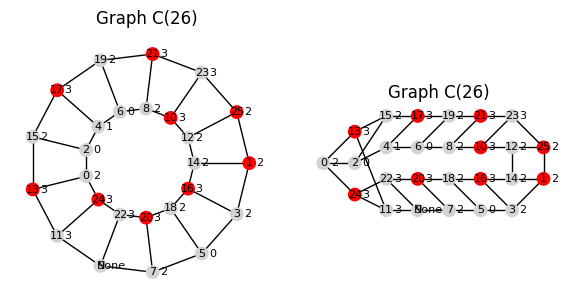

[1, 10, 13, 16, 17, 20, 21, 24, 25]
13
Removed node: None
Healthy nodes after spread: [0, 2, 13, 15]


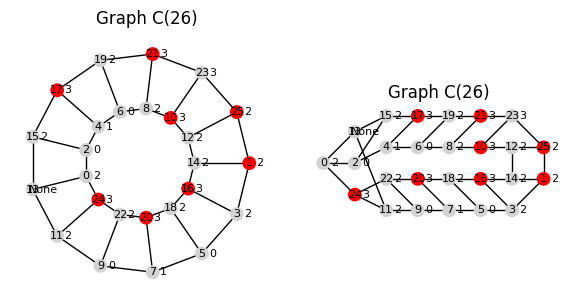

[1, 10, 16, 17, 20, 21, 24, 25]
17
Removed node: None
Healthy nodes after spread: [0, 2, 4, 6, 13, 15, 17, 19]


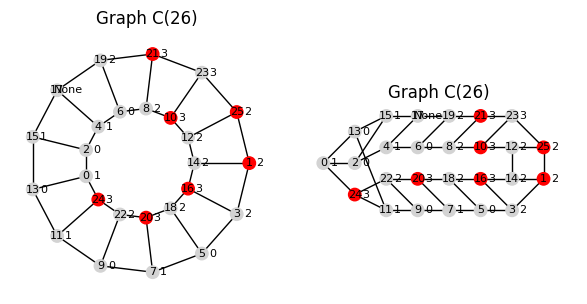

[1, 10, 16, 20, 21, 24, 25]
20
Removed node: None
Healthy nodes after spread: [0, 2, 4, 5, 6, 7, 9, 11, 13, 15, 17, 18, 19, 20, 22]


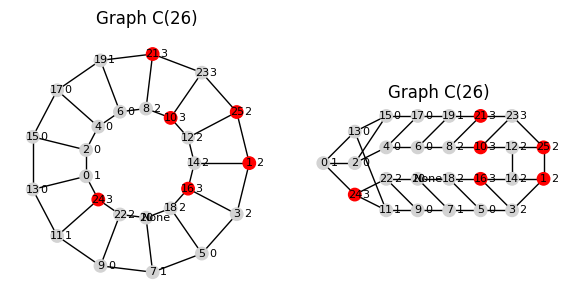

[1, 10, 16, 21, 24, 25]
21
Removed node: None
Healthy nodes after spread: [0, 2, 4, 5, 6, 7, 8, 9, 11, 13, 15, 17, 18, 19, 20, 21, 22]


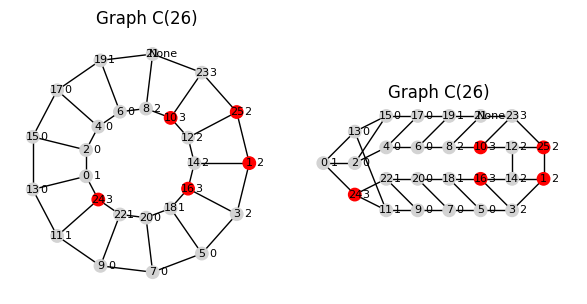

[]


In [12]:
G, n, _ = generate_graphs(26)[1]     # prism
fully_infect(G)
calc_graph_values(G)
display_graph_stage(G, prism=True)

# 1. stage
print("initial removal")
minimise_infection(G, 0)
pc = calc_graph_values(G)
display_graph_stage(G, prism=True, figsize=(8, 4))

# print(pc)
calc_values(G)

def get_candidate(G):
    for i in G.nodes:
        e = G.nodes[i]
        # print(i, e)
        if e.get("infected"):
            adj = G.adj[i]
            c = 0
            for x in adj:
                z =  G.nodes[x]
                if G.nodes[x].get("infected_n") - 1 >= 2:
                    c += 1

            if c >= 3:
                return i


for _ in range(20):
    pc = calc_graph_values(G)
    print(pc)

    if len(pc) == 0:
        break
    
    c = get_candidate(G)
    print(c)

    G.nodes[c]["infected"] = False
    print("Removed node:", removed)

    H, infected_nodes, healthy_nodes = fully_endemic(G)
    print("Healthy nodes after spread:", healthy_nodes)

    display_graph_stage(G, prism=True)
